# COMPUTACIÓN DE ALTAS PRESTACIONES - Práctica 2
## Autor: Iván Domínguez

### Ejercicio 3

La idea es simple para este código. Implementaremos el mismo algoritmo que para la práctica anterior, salvo que ahora asignaremos un hilo a cada elemento de la matriz. Siguiendo las recomendaciones del enunciado, lo óptimo es hacerlo teniendo en cuenta un problema bidimensional (es decir 2D, 2 índices en lugar de 1). 

Recordamos que esta versión está ejecutada desde Kaggle. Para poder procesar las imágenes, se ha añadido un dataset con tan solo 2 de las imágenes de la primera práctica (las de mayor calidad, 4 y 8k). Creemos que procesar otras imágenes usando la gráfica sería una pérdida de tiempo. 

In [1]:
import matplotlib
import matplotlib.image as pltim
import matplotlib.pyplot as plt
import numpy as np
import time
import os

# Cargamos el folder del dataset de Kaggle (desde donde ejecutamos este código).
folder = '/kaggle/input/datasets/idomh2005/images'

# La función para listar archivos es exactamente la misma. 
def list_jpg_files(folder_path):
  jpg_files = []
  for filename in os.listdir(folder_path):
    if filename.lower().endswith(".jpg"):
      jpg_files.append(filename)
  return jpg_files

# Cargamos la lista de archivos.
jpg_files_list = list_jpg_files(folder)

# La función para visualizar las imágenes es la misma que en la primera práctica:
def showImage(image):
  plt.imshow(image, cmap = matplotlib.cm.Greys_r)
  plt.show()

In [2]:
from numba import cuda

# Lo que tendremos que cambiar es la función de procesamiento de imagen. 

@cuda.jit
def rgb2gray(image, greyImage):

    # el bucle desaparece, ahora cada hilo tiene asociado un elemento de la matriz 
    [i,j] = cuda.grid(2)

    if i < image.shape[0] and j < image.shape[1]:
        cuda.syncthreads()
        greyImage[i][j] = np.int8(image[i][j][0]*0.2989 + image[i][j][1]*0.5870 + image[i][j][2] * 0.1140)

Ahora recorreremos las imágenes del directorio. Pero antes, no vendría mal una llamada en frío a la función de procesamiento para que compile. 

**Una nota antes de codificar**: la imagen '8k.jpg' tiene dimensiones (7680 x 4320). Esto son casi 34 millones de píxeles, por lo que una gráfica funcionará bien si le fijamos un número de hilos parecido o mayor, pero nunca menor. Por ejemplo, 32x32 hilos por bloque, con 256x256 bloques por grid, son 67M de hilos, suficiente para procesar una imagen de estas dimensiones. Pero usando 16x16 hilos por bloque, con 256x256 bloques por grid, tenemos 16M de hilos, menos de la mitad de los necesarios para procesar la imagen. Y tal y como está definido nuestro código, solo se contempla el caso en el que "sobran" hilos, no el que faltan, por lo que aquellos píxeles sin procesar volveran negros, ruido o simplemente valores sin procesar. 

**Conclusión**: deberíamos usar 32x32 hilos por bloque, con 256x256 bloques por grid para procesar imágenes de 8k, aunque sobrarán hilos para procesar las de 4k. 

Processing image /kaggle/input/datasets/idomh2005/images/SD.jpg
360 640
Execution time: 1.664554 seconds
Copying-to-host time: 0.001205 seconds 



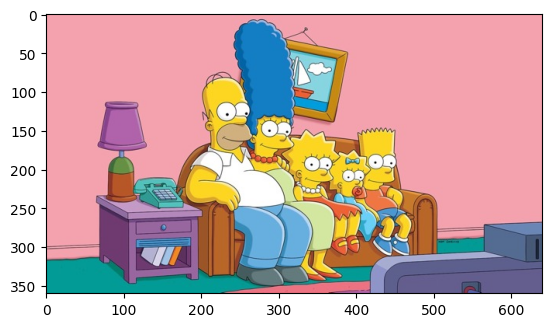

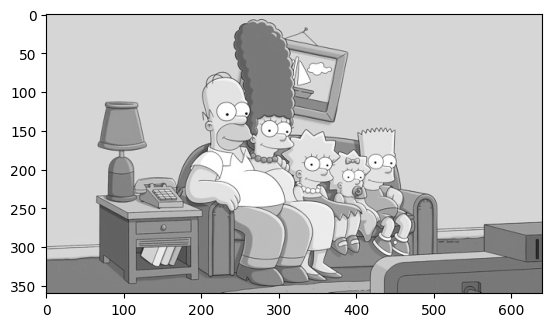

Processing image /kaggle/input/datasets/idomh2005/images/HD.jpg
720 1280
Execution time: 0.000184 seconds
Copying-to-host time: 0.001781 seconds 



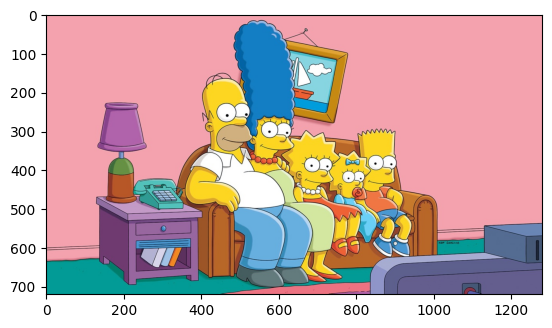

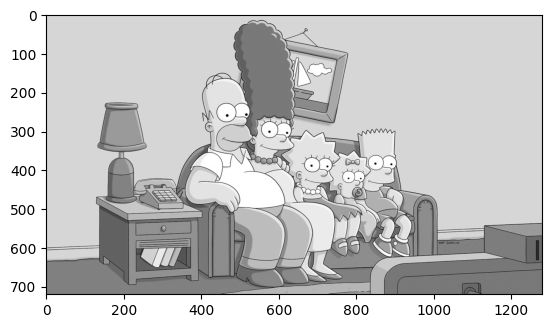

Processing image /kaggle/input/datasets/idomh2005/images/8k.jpg
4320 7680
Execution time: 0.000199 seconds
Copying-to-host time: 0.028040 seconds 



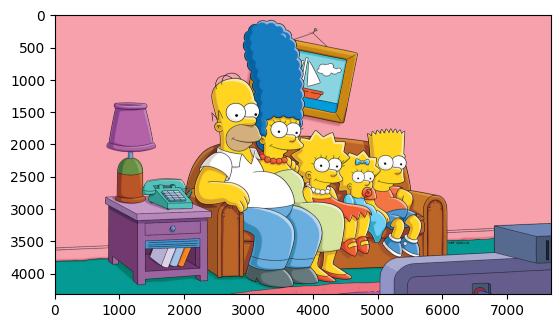

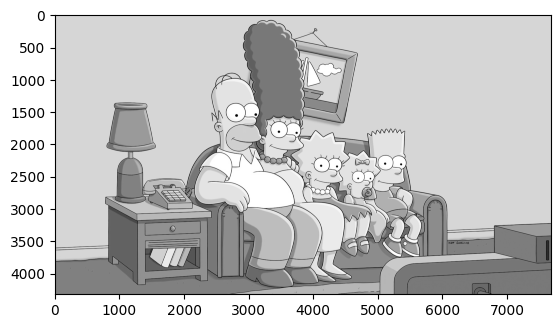

Processing image /kaggle/input/datasets/idomh2005/images/4k.jpg
2160 3840
Execution time: 0.000188 seconds
Copying-to-host time: 0.006518 seconds 



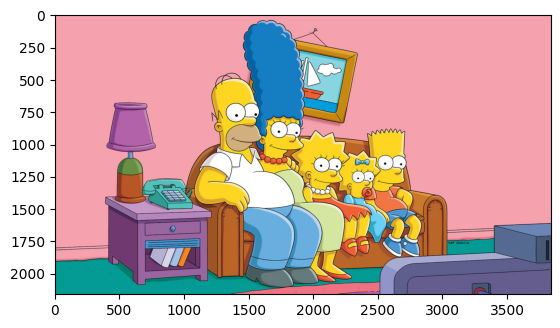

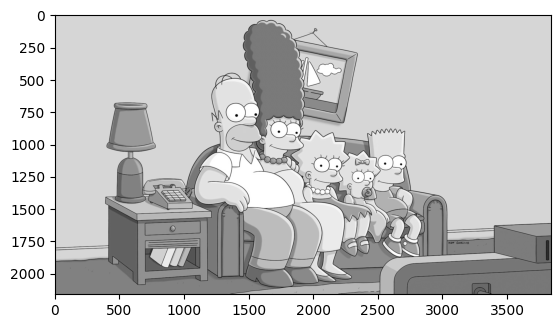

Processing image /kaggle/input/datasets/idomh2005/images/FHD.jpg
1080 1920
Execution time: 0.000237 seconds
Copying-to-host time: 0.002413 seconds 



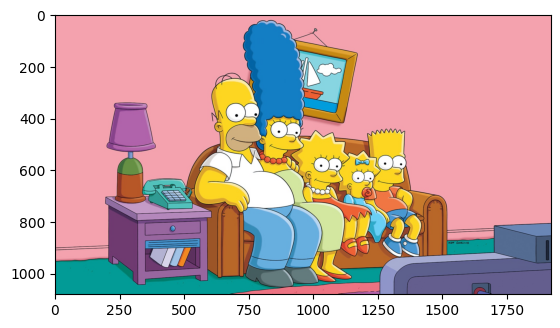

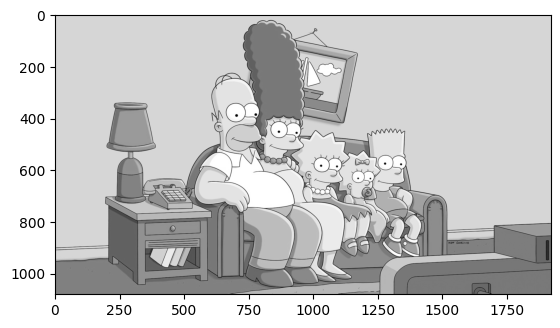

In [3]:
# Definimos hilos y número de bloques por hilo:

threadsperblock = (32, 32) 
blockspergrid = (256, 256) 

for image_file in jpg_files_list:

    image_file = folder+"/"+ image_file
    image = pltim.imread(image_file)
    image = np.copy(image)
    d_image=cuda.to_device(image)
    print(f"Processing image {image_file}")
    
    # Creamos la imagen de salida fuera del kernel de CUDA 
    
    imageHeight, imageWidth = image.shape[0], image.shape[1]
    print(imageHeight, imageWidth)
    greyImage = np.empty((imageHeight, imageWidth), dtype=np.uint8)
    d_greyImage = cuda.to_device(greyImage)
    
    start_time = time.time()
    
    rgb2gray[blockspergrid, threadsperblock](d_image, d_greyImage)
    
    end_time = time.time()
    execution_time = end_time - start_time
    print(f"Execution time: {execution_time:.6f} seconds")

    s_time = time.time()
    d_greyImage.copy_to_host()
    e_time = time.time()
    traer_de_vuelta = e_time - s_time
    print(f"Copying-to-host time: {traer_de_vuelta:.6f} seconds \n")

    # como usa CPU para visualizar, tarda demasiado al ser la de Kaggle:
    
    showImage(image) 
    showImage(d_greyImage)

Viendo que esto funciona correctamente, podemos hacer muchas llamadas a la misma función para imágenes en 4k y 8k, como se comentaba anteriormente. 

Es un poco desperdicio pasar a GPU las imágenes para luego solo procesarlas una única vez. Es trivial ver que el tiempo de procesado es una centésima parte del tiempo de llevar o traer la imagen de/a la memoria principal/la de la GPU. Por tanto, parece lógico pensar que, para estudiar el rendimiento real del programa ejecutado desde le gráfica, deberíamos contar todo el ciclo del dato, desde que sale de la memoria principal hasta que vuelve a entrar (que es lo que haría un programa de procesado de imágenes real). Además, para estudiarlo adecuadamente, pasaremos una cantidad masiva de imágenes de la máxima resolución posible para ser lo más pesimistas posibles en cuanto a la información que un tal programa tendría que procesar (raro sería procesar únicamente imágenes de 8k, pero parece una aproximación razonable para el peor escenario). Se muestra a continuación esta forma de hacerlo. 

In [4]:
# Y ahora llamamos al bloque de procesamiento

n_iter = 10**3
tiempo_total = np.zeros(n_iter)

# procesaremos la imagen de 8k 

image_file = folder +"/"+ '8k.jpg'
image = pltim.imread(image_file)
image = np.copy(image)
imageHeight, imageWidth = image.shape[0], image.shape[1]
# pasamos a la GPU la imagen (no cambia inplace, basta con hacerlo una vez)
d_image=cuda.to_device(image)
greyImage = np.empty((imageHeight, imageWidth), dtype=np.uint8)

for i in range(n_iter):

    start_time = time.time()
    
    # pasamos a la GPU la nueva imagen
    d_greyImage = cuda.to_device(greyImage)

    # procesamiento de la imagen
    rgb2gray[blockspergrid, threadsperblock](d_image, d_greyImage)

    # traer de vuelta la imagen
    d_greyImage.copy_to_host()

    end_time = time.time()
    execution_time = end_time - start_time

    tiempo_total[i]=execution_time

tiempo_medio = np.mean(tiempo_total)

print(f'El tiempo medio ida, procesamiento y vuelta es de {tiempo_medio}s.')

El tiempo medio ida, procesamiento y vuelta es de 0.020531853914260864s.


**Nota**: cuando la sesión de Kaggle ofrece una gráfica, la capacidad de CPU disminuye drásticamente. Por ello, todas las tareas de visualización han sido eliminadas, pues están encargadas a la CPU. Solo se miden las relativas a la GPU. Por ello, parece razonable hacer una única transferencia de datos: una en la que se pasen, por ejemplo, 100 veces la misma imagen. Por ejemplo, en forma de collage. Es decir, una matriz $(10\times10)$, cuyos elementos sean todos el mismo e iguales a la imagen 8k. Es fácil hacer esto con numpy:

Ahora deberíamos encarar el problema pensando en 4 distintas dimensiones: las 2 respectivas a cada imagen (cada elemento de la matriz nueva_imagen), así como las 2 referentes a las dimensiones de cada una de las matrices (los píxeles). Para ello, diseñaremos otro kernel de CUDA capaz de tener en cuenta esas nuevas 2 dimensiones añadidas y que llame al kernel anterior en para procesar las imágenes:

In [5]:
image_file = folder + "/" + "8k.jpg"
image = pltim.imread(image_file)

H, W, C = image.shape
N, M =  3, 3

image_matrix_cpu  = np.zeros((N, M, H, W, C), dtype=np.uint8)
output_matrix_cpu = np.zeros((N, M, H, W),    dtype=np.float32)

for i in range(N):
    for j in range(M):
        image_matrix_cpu[i][j] = np.copy(image)

Creamos el nuevo kernel de CUDA:

In [6]:
# habría que cambiar ligeramente el kernel anterior, especialmente 
# para añadirle device=True al decorador y poder llamarlo dentro del
# kernel que queremos diseñar.

@cuda.jit(device=True)
def rgb2gray_device(image, greyImage, i, j):
    i, j, _ = cuda.grid(3)
    if i < image.shape[0] and j < image.shape[1]:
        greyImage[i][j] = (
            image[i][j][0] * 0.2989 +
            image[i][j][1] * 0.5870 +
            image[i][j][2] * 0.1140
        )

@cuda.jit
def process_all_images(image_matrix, output_matrix):
    i, j, img_idx = cuda.grid(3)

    N = image_matrix.shape[0]
    M = image_matrix.shape[1]
    H = image_matrix.shape[2]
    W = image_matrix.shape[3]

    n = img_idx // M
    m = img_idx % M

    if i < H and j < W and n < N and m < M:
        rgb2gray_device(image_matrix[n, m], output_matrix[n, m], i, j)

Definimos una nueva matriz de tamaño arbitrario $3\times3$ (es decir, meteremos la imagen 8k en los 9 elementos de la matriz). 

In [7]:
THREADS_PER_BLOCK = (16, 16, 4)

blocks_x = (H   + THREADS_PER_BLOCK[0] - 1) // THREADS_PER_BLOCK[0]
blocks_y = (W   + THREADS_PER_BLOCK[1] - 1) // THREADS_PER_BLOCK[1]
blocks_z = (N*M + THREADS_PER_BLOCK[2] - 1) // THREADS_PER_BLOCK[2]

BLOCKS_PER_GRID = (blocks_x, blocks_y, blocks_z)

In [8]:
t_ini = time.time()

image_matrix_gpu  = cuda.to_device(image_matrix_cpu)
output_matrix_gpu = cuda.to_device(output_matrix_cpu)

process_all_images[BLOCKS_PER_GRID, THREADS_PER_BLOCK](
    image_matrix_gpu,
    output_matrix_gpu
)

cuda.synchronize()
result = output_matrix_gpu.copy_to_host()

t_fin = time.time()

print(f"Número de imágenes procesadas: {result.shape[0]*result.shape[1]} \n Tiempo total: {t_fin-t_ini} ") 

Número de imágenes procesadas: 9 
 Tiempo total: 1.4483449459075928 


Es importante no quedarse sin RAM. Podemos hacer un cálculo de cuántas imágenes cabrían en los 15GB disponibles para la GPU de Kaggle (que en realidad son 10GB, que son los que caben en la CPU al traerlas de vuelta procesadas):

Cada imagen de entrada (bits de tipo int8):

$$7680 \times 4320 \times 3 \times 1 byte \approx 94.92MB$$

Cada imagen de salida: 

$$7680 \times 4320 \times 4 bytes \approx 126.56MB$$

Por lo tanto para 50 imágenes, por ejemplo, ocuparíamos:

$$ 50 \times (94.92MB + 126.56MB) \approx 11GB $$

Por lo que un tal tamaño ya no cabría en la CPU. Probaremos por tanto con matrices de, como mucho 36 imágenes. 

In [9]:
image_file = folder + "/" + "8k.jpg"
image = pltim.imread(image_file)

for n_ima in range(3, 7):

    H, W, C = image.shape
    N, M =  n_ima, n_ima # n_ima x n_ima imágenes
    
    image_matrix_cpu  = np.zeros((N, M, H, W, C), dtype=np.uint8)
    output_matrix_cpu = np.zeros((N, M, H, W),    dtype=np.float32)
    
    for i in range(N):
        for j in range(M):
            image_matrix_cpu[i][j] = np.copy(image)
    
    t_ini = time.time()
    
    image_matrix_gpu  = cuda.to_device(image_matrix_cpu)
    output_matrix_gpu = cuda.to_device(output_matrix_cpu)
    
    process_all_images[BLOCKS_PER_GRID, THREADS_PER_BLOCK](
        image_matrix_gpu,
        output_matrix_gpu
    )
    
    cuda.synchronize()
    result = output_matrix_gpu.copy_to_host()
    
    t_fin = time.time()
    
    print(f"Número de imágenes procesadas: {result.shape[0]*result.shape[1]} \n Tiempo total: {t_fin-t_ini} \n ") 

Número de imágenes procesadas: 9 
 Tiempo total: 1.2713804244995117 
 
Número de imágenes procesadas: 16 
 Tiempo total: 2.2199556827545166 
 
Número de imágenes procesadas: 25 
 Tiempo total: 3.3877806663513184 
 
Número de imágenes procesadas: 36 
 Tiempo total: 4.935137987136841 
 


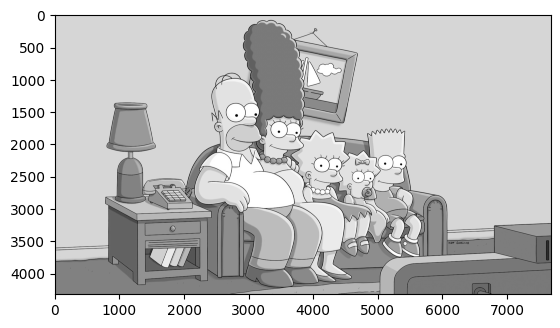

In [10]:
# Podemos probar que se hayan procesado correctamente las imágenes
# pasando por pantalla una escogida aleatoriamente:

i = np.random.randint(0, output_matrix_gpu.shape[0] - 1)
j = np.random.randint(0, output_matrix_gpu.shape[1] - 1)

showImage(output_matrix_gpu[i][j]) 

Resultados: 

- Las imágenes se procesan correctamente. Se devuelve una matriz de objetos imagen procesadas correctamente cada una.

- El resultado promedio son unos 7fps, lo que si bien es cierto que es un buen rendimiento para las imágenes de 8k, es inasumible para una implementación cotidiana. No es un buen resultado.

Se podría probar procesar imágenes de 4k en lugar de 8k. El rendimiento del programa será mucho mejor y, aún así, probablemente el potencial usuario ni si quiera pueda notar la diferencia.

In [11]:
image_file = folder + "/" + "4k.jpg"
image = pltim.imread(image_file)

for n_ima in range(3, 7):

    H, W, C = image.shape
    N, M =  n_ima, n_ima # n_ima x n_ima imágenes

    blocks_x = (H   + THREADS_PER_BLOCK[0] - 1) // THREADS_PER_BLOCK[0]
    blocks_y = (W   + THREADS_PER_BLOCK[1] - 1) // THREADS_PER_BLOCK[1]
    blocks_z = (N*M + THREADS_PER_BLOCK[2] - 1) // THREADS_PER_BLOCK[2]
    BLOCKS_PER_GRID = (blocks_x, blocks_y, blocks_z)
    
    image_matrix_cpu  = np.zeros((N, M, H, W, C), dtype=np.uint8)
    output_matrix_cpu = np.zeros((N, M, H, W),    dtype=np.float32)
    
    for i in range(N):
        for j in range(M):
            image_matrix_cpu[i][j] = np.copy(image)
    
    t_ini = time.time()
    
    image_matrix_gpu  = cuda.to_device(image_matrix_cpu)
    output_matrix_gpu = cuda.to_device(output_matrix_cpu)
    
    process_all_images[BLOCKS_PER_GRID, THREADS_PER_BLOCK](
        image_matrix_gpu,
        output_matrix_gpu
    )
    
    cuda.synchronize()
    result = output_matrix_gpu.copy_to_host()
    
    t_fin = time.time()
    
    print(f"Número de imágenes procesadas: {result.shape[0]*result.shape[1]} \n Tiempo total: {t_fin-t_ini} \n ") 

Número de imágenes procesadas: 9 
 Tiempo total: 0.37458014488220215 
 
Número de imágenes procesadas: 16 
 Tiempo total: 0.5585083961486816 
 
Número de imágenes procesadas: 25 
 Tiempo total: 0.8702616691589355 
 
Número de imágenes procesadas: 36 
 Tiempo total: 1.2581984996795654 
 


En efecto, conseguimos unos tiempos maginificos, unos 30fps para el peor de los casos. Y no olvidemos que esto ni si quiera es el tiempo de procesamiento. Probablemente más del 70% de este tiempo sea el tiempo en pasar la matriz de imágenes a GPU y luego de vuelta a la GPU. 

Podemos crear un DataFrame y compararlo con lo que obtuvimos en la práctica anterior:

In [12]:
tiempos_de_ejecucion = []

for imagen in ['4k.jpg', '8k.jpg', 'FHD.jpg', 'SD.jpg', 'HD.jpg']:

    image_file = folder + "/" + imagen
    image = pltim.imread(image_file)
    
    for n_ima in range(3, 7):
    
        H, W, C = image.shape
        N, M =  n_ima, n_ima # n_ima x n_ima imágenes

        blocks_x = (H   + THREADS_PER_BLOCK[0] - 1) // THREADS_PER_BLOCK[0]
        blocks_y = (W   + THREADS_PER_BLOCK[1] - 1) // THREADS_PER_BLOCK[1]
        blocks_z = (N*M + THREADS_PER_BLOCK[2] - 1) // THREADS_PER_BLOCK[2]
        BLOCKS_PER_GRID = (blocks_x, blocks_y, blocks_z)
        
        image_matrix_cpu  = np.zeros((N, M, H, W, C), dtype=np.uint8)
        output_matrix_cpu = np.zeros((N, M, H, W),    dtype=np.float32)
        
        for i in range(N):
            for j in range(M):
                image_matrix_cpu[i][j] = np.copy(image)
        
        t_ini = time.time()
        
        image_matrix_gpu  = cuda.to_device(image_matrix_cpu)
        output_matrix_gpu = cuda.to_device(output_matrix_cpu)
        
        process_all_images[BLOCKS_PER_GRID, THREADS_PER_BLOCK](
            image_matrix_gpu,
            output_matrix_gpu
        )
        
        cuda.synchronize()
        result = output_matrix_gpu.copy_to_host()
        
        t_fin = time.time()
        
        print(f"Imagen {imagen}. Número de imágenes procesadas: {result.shape[0]*result.shape[1]} \n Tiempo total: {t_fin-t_ini} \n ")

    tiempos_de_ejecucion.append(t_fin-t_ini) # guardamos el tiempo de ejecución de la última llamada

Imagen 4k.jpg. Número de imágenes procesadas: 9 
 Tiempo total: 0.3653695583343506 
 
Imagen 4k.jpg. Número de imágenes procesadas: 16 
 Tiempo total: 0.5477933883666992 
 
Imagen 4k.jpg. Número de imágenes procesadas: 25 
 Tiempo total: 0.8629813194274902 
 
Imagen 4k.jpg. Número de imágenes procesadas: 36 
 Tiempo total: 1.2767338752746582 
 
Imagen 8k.jpg. Número de imágenes procesadas: 9 
 Tiempo total: 1.2770404815673828 
 
Imagen 8k.jpg. Número de imágenes procesadas: 16 
 Tiempo total: 2.2469310760498047 
 
Imagen 8k.jpg. Número de imágenes procesadas: 25 
 Tiempo total: 3.5472629070281982 
 
Imagen 8k.jpg. Número de imágenes procesadas: 36 
 Tiempo total: 5.05698823928833 
 
Imagen FHD.jpg. Número de imágenes procesadas: 9 
 Tiempo total: 0.11189031600952148 
 
Imagen FHD.jpg. Número de imágenes procesadas: 16 
 Tiempo total: 0.19212746620178223 
 
Imagen FHD.jpg. Número de imágenes procesadas: 25 
 Tiempo total: 0.2238602638244629 
 
Imagen FHD.jpg. Número de imágenes procesad

In [13]:
import pandas as pd

my_dict = {}

imagenes = ['4k', '8k', 'FHD', 'SD', 'HD']
for a, b in zip(imagenes, tiempos_de_ejecucion):
    my_dict[a] = b 

df = pd.DataFrame.from_dict(my_dict, orient='index', columns=['Tiempo de ida, procesamiento y vuelta'])
df['fps'] = 36/df['Tiempo de ida, procesamiento y vuelta']

df

,"Tiempo de ida, procesamiento y vuelta",fps
4k,1.276734,28.196949
8k,5.056988,7.118862
FHD,0.307816,116.952974
SD,0.048383,744.070369
HD,0.145430,247.541217


Recordando el DataFrame de la práctica anterior, podemos ver que el rendimiento no es mejor para ninguno de los pesos de imagen:

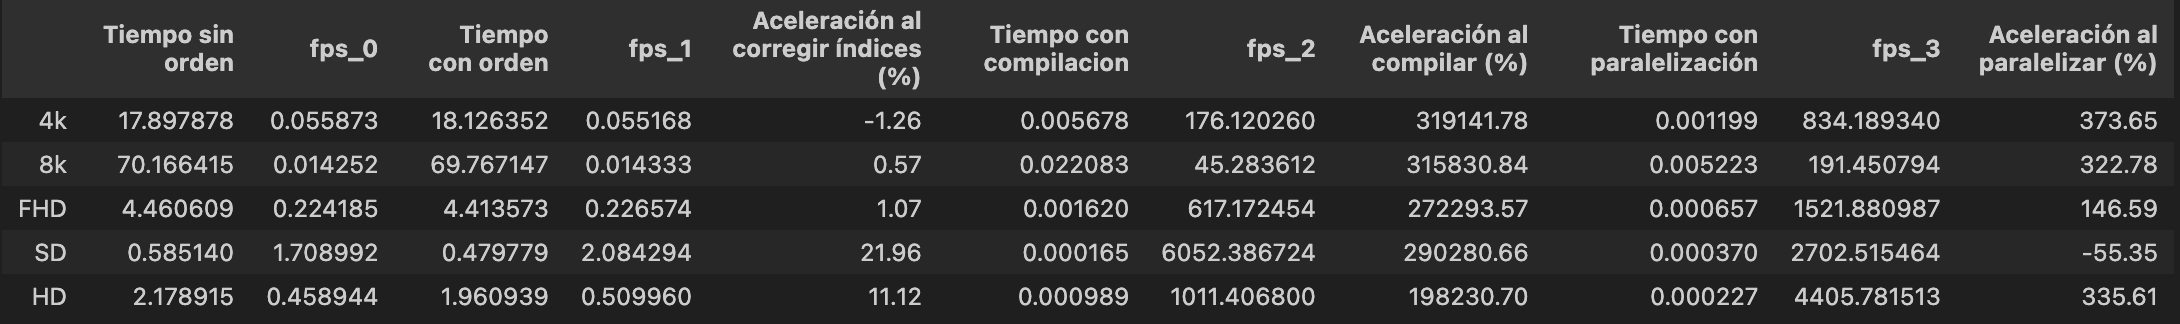

Queda claro que si bien la gráfica promete mucho mejores resultados, su limitante sigue siendo el cuello de botella que genera la CPU al mover los resultados entre la memoria CPU y la GPU. El siguiente paso sería eliminar esta limitación unificando la memoria entre la CPU y la GPU, pero esto es algo que Kaggle no ofrece, desde luego. 

Por último, respondiendo a cómo haría para mejorar el algoritmo: 

- Memoria compartida: cargar píxeles en shared memory antes de operar, evitando accesos repetidos a memoria global (lenta).
  
- Cercanía en memoria: los accesos a image[i][j][c] son contiguos en memoria gracias al orden row-major de NumPy, lo que maximiza el ancho de banda. En teoría esto ya debería ser óptimo. 

- Evitar divergencia de warp: el if i < H and j < W causa que algunos threads no trabajen, minimizable eligiendo tamaños de bloque que dividan bien las dimensiones de la imagen.

- Occupancy: bloques de (16, 16, 4) = 1024 threads (máximo por bloque), maximizando la ocupación de los SMs.

- Memoria pinned: usar cuda.pinned_array en CPU para acelerar transferencias CPU↔GPU.